In [295]:
# importing the necessary librarires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets

In [296]:
player_info_df = pd.read_csv('players_info.csv')
player_seasonal_df = pd.read_csv('seasonal_stats.csv')
player_match_level_df = pd.read_csv('afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv')

In [297]:
# Inspect data structure and types

In [298]:
player_info_df.shape

(2843, 14)

In [299]:
player_seasonal_df.shape

(25481, 54)

In [300]:
player_match_level_df.shape

(274089, 36)

In [301]:
player_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2843 entries, 0 to 2842
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                2843 non-null   int64 
 1   player_name       2843 non-null   object
 2   player_full_name  2843 non-null   object
 3   first_name        2843 non-null   object
 4   last_name         2843 non-null   object
 5   born_date         2843 non-null   object
 6   debut_date        2843 non-null   object
 7   debut_age         2843 non-null   int64 
 8   last_date         2843 non-null   object
 9   last_age          2843 non-null   int64 
 10  height            2843 non-null   int64 
 11  weight            2843 non-null   int64 
 12  player_link       2843 non-null   object
 13  player_teams      2843 non-null   object
dtypes: int64(5), object(9)
memory usage: 311.1+ KB


In [302]:
player_seasonal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25481 entries, 0 to 25480
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    25481 non-null  int64  
 1   year                         25481 non-null  int64  
 2   team                         25481 non-null  object 
 3   is_finals                    25481 non-null  bool   
 4   games_played                 25481 non-null  int64  
 5   kicks                        25481 non-null  float64
 6   marks                        25481 non-null  float64
 7   handballs                    25481 non-null  float64
 8   disposals                    25481 non-null  float64
 9   goals                        25481 non-null  float64
 10  behinds                      25481 non-null  float64
 11  hit_outs                     25481 non-null  float64
 12  tackles                      25481 non-null  float64
 13  rebound_50s     

In [303]:
player_match_level_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274089 entries, 0 to 274088
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274089 non-null  int64  
 1   team                       274089 non-null  object 
 2   year                       274089 non-null  int64  
 3   career_game_count          274089 non-null  int64  
 4   opponent                   274089 non-null  object 
 5   round                      274089 non-null  object 
 6   result                     274089 non-null  object 
 7   jersey_num                 274089 non-null  int64  
 8   kicks                      272789 non-null  float64
 9   marks                      266038 non-null  float64
 10  handballs                  269656 non-null  float64
 11  disposals                  265636 non-null  float64
 12  goals                      199352 non-null  float64
 13  behinds                    19

# Check for the missing values

In [304]:
# count missing values per column
print(player_info_df.isnull().sum())

id                  0
player_name         0
player_full_name    0
first_name          0
last_name           0
born_date           0
debut_date          0
debut_age           0
last_date           0
last_age            0
height              0
weight              0
player_link         0
player_teams        0
dtype: int64


In [305]:
print(player_seasonal_df.isnull().sum())

player_id                      0
year                           0
team                           0
is_finals                      0
games_played                   0
kicks                          0
marks                          0
handballs                      0
disposals                      0
goals                          0
behinds                        0
hit_outs                       0
tackles                        0
rebound_50s                    0
inside_50s                     0
clearances                     0
clangers                       0
free_kicks_for                 0
free_kicks_against             0
brownlow_votes                 0
contested_possessions          0
uncontested_possessions        0
contested_marks                0
marks_inside_50                0
one_percenters                 0
bounces                        0
goal_assists                   0
total_score                    0
total_fantasy_points           0
total_percentage_played        0
avg_kicks 

In [306]:
print(player_match_level_df.isnull().sum())

id                                0
team                              0
year                              0
career_game_count                 0
opponent                          0
round                             0
result                            0
jersey_num                        0
kicks                          1300
marks                          8051
handballs                      4433
disposals                      8453
goals                         74737
behinds                       81093
hit_outs                      96629
tackles                       28682
rebound_50s                   62856
inside_50s                    46574
clearances                    63919
clangers                      49965
free_kicks_for                53842
free_kicks_against            53275
brownlow_votes               110481
contested_possessions         38826
uncontested_possessions       37998
contested_marks               90677
marks_inside_50               91378
one_percenters              

# Handeling the null values

In [307]:
#  Drop the 'score' column since it is 100% null (all values are NaN)
if 'score' in player_match_level_df.columns:
    player_match_level_df = player_match_level_df.drop(columns=['score'])

In [308]:

#  Define the list of performance statistic columns that should be filled with 0
stat_cols = [
    'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs',
    'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers',
    'free_kicks_for', 'free_kicks_against', 'brownlow_votes',
    'contested_possessions', 'uncontested_possessions', 'contested_marks',
    'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist', 'percentage_of_game_played'
]

# Fill missing values with 0 for these performance stats
player_match_level_df[stat_cols] = player_match_level_df[stat_cols].fillna(0)

In [309]:
# Verify that no missing values remain in these columns
print("Remaining missing values in stats:", player_match_level_df[stat_cols].isnull().sum().sum())
print("Cleaned dataframe shape:", player_match_level_df.shape)

Remaining missing values in stats: 0
Cleaned dataframe shape: (274089, 35)


# Check for duplicate rows

In [310]:
print("Duplicates in player_info:", player_info_df.duplicated().sum())

Duplicates in player_info: 0


In [311]:
print("Duplicates in player_seasonal_stats:", player_seasonal_df.duplicated().sum())

Duplicates in player_seasonal_stats: 0


In [312]:
print("Duplicates in player_match_level_stats:", player_match_level_df.duplicated().sum())

Duplicates in player_match_level_stats: 10


Drop the diplicate rows

In [313]:
player_match_level_df = player_match_level_df.drop_duplicates()

In [314]:
print("Duplicates in player_match_level_stats:", player_match_level_df.duplicated().sum())

Duplicates in player_match_level_stats: 0


Generate Summary Statistic

In [315]:
player_info_df.describe()

,id,debut_age,last_age,height,weight
count,2843.000000,2843.000000,2843.000000,2843.000000,2843.000000
mean,44861.425607,19.594442,25.761520,187.333802,85.998945
std,910.799569,1.820537,4.338846,7.315601,8.921445
min,43260.000000,16.000000,18.000000,163.000000,0.000000
25%,44067.500000,18.000000,22.000000,182.000000,80.000000
50%,44888.000000,19.000000,25.000000,187.000000,85.000000
75%,45663.500000,20.000000,29.000000,192.000000,92.000000
max,46374.000000,29.000000,40.000000,211.000000,118.000000


In [316]:
player_match_level_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274079 entries, 0 to 274088
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274079 non-null  int64  
 1   team                       274079 non-null  object 
 2   year                       274079 non-null  int64  
 3   career_game_count          274079 non-null  int64  
 4   opponent                   274079 non-null  object 
 5   round                      274079 non-null  object 
 6   result                     274079 non-null  object 
 7   jersey_num                 274079 non-null  int64  
 8   kicks                      274079 non-null  float64
 9   marks                      274079 non-null  float64
 10  handballs                  274079 non-null  float64
 11  disposals                  274079 non-null  float64
 12  goals                      274079 non-null  float64
 13  behinds                    274079 

In [317]:
player_seasonal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25481 entries, 0 to 25480
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    25481 non-null  int64  
 1   year                         25481 non-null  int64  
 2   team                         25481 non-null  object 
 3   is_finals                    25481 non-null  bool   
 4   games_played                 25481 non-null  int64  
 5   kicks                        25481 non-null  float64
 6   marks                        25481 non-null  float64
 7   handballs                    25481 non-null  float64
 8   disposals                    25481 non-null  float64
 9   goals                        25481 non-null  float64
 10  behinds                      25481 non-null  float64
 11  hit_outs                     25481 non-null  float64
 12  tackles                      25481 non-null  float64
 13  rebound_50s     

In [318]:

# for categorical columns summary
player_info_df.describe(include=['O'])

,player_name,player_full_name,first_name,last_name,born_date,debut_date,last_date,player_link,player_teams
count,2843,2843,2843,2843,2843,2843,2843,2843,2843
unique,2826,2843,742,1998,2546,1610,1305,2843,310
top,Aaron Black,Dylan_Shiel,Tom,Smith,1989-10-09,2012-03-24,2025-08-22,https://afltables.com/afl/stats/players/D/Dyla...,{Essendon Bombers}
freq,2,1,63,24,4,15,67,1,131


In [319]:

player_seasonal_df.describe(include=['O'])

,team
count,25481
unique,114
top,Geelong Cats
freq,1258


In [320]:

player_match_level_df.describe(include=['O'])

,team,opponent,round,result,match_date
count,274079,274079,274079,274079,274079
unique,20,20,30,3,3276
top,Geelong Cats,Geelong Cats,18,W,2015-09-05
freq,16902,16831,11909,136261,270


In [321]:

# Strip leading and trailing whitespace from all string columns in all dataframes
for df in [player_info_df, player_seasonal_df, player_match_level_df]:
    object_cols = df.select_dtypes(include=['object']).columns
    for col in object_cols:
        df[col] = df[col].astype(str).str.strip()

In [322]:
# Standardize team name casing across dataframes to avoid duplication issues
for df in [player_seasonal_df, player_match_level_df]:
    if 'team' in df.columns:
        df['team'] = df['team'].str.title()

# 1: Identify the Top 10 Most Valuable Players

In [323]:
#  creating the goal conversion feature
player_seasonal_df['goal_conversion'] = np.where(
    (player_seasonal_df['goals'] + player_seasonal_df['behinds']) > 0,
    player_seasonal_df['goals'] / (player_seasonal_df['goals'] + player_seasonal_df['behinds']),
    0.0
)

In [324]:
# Printing the Goal Conversion feature to verify it worked
print(player_seasonal_df[['player_id', 'year', 'goals', 'behinds', 'goal_conversion']].head())

   player_id  year  goals  behinds  goal_conversion
0      43261  2018    3.0      2.0         0.600000
1      43261  2018    0.0      1.0         0.000000
2      43261  2019    1.0      0.0         1.000000
3      43261  2020    1.0      0.0         1.000000
4      43262  2002   10.0      3.0         0.769231


Formula: contested_possessions / disposals

In [325]:
player_seasonal_df['disposal_impact'] = np.where(player_seasonal_df['disposals'] > 0,
                                               player_seasonal_df['contested_possessions'] / player_seasonal_df['disposals'],
                                                 0.0)

In [326]:
print("Disposal Impact feature created successfully!")
print(player_seasonal_df[['player_id', 'year', 'disposals', 'contested_possessions', 'disposal_impact']].head())

Disposal Impact feature created successfully!
   player_id  year  disposals  contested_possessions  disposal_impact
0      43261  2018       38.0                   20.0         0.526316
1      43261  2018        5.0                    2.0         0.400000
2      43261  2019       11.0                    6.0         0.545455
3      43261  2020        3.0                    0.0         0.000000
4      43262  2002      100.0                   68.0         0.680000


In [327]:

player_seasonal_df['fantasy_pts_per_game'] = player_seasonal_df['avg_fantasy_points']

In [328]:
print(player_seasonal_df[['player_id', 'year', 'avg_fantasy_points', 'fantasy_pts_per_game']].head())

   player_id  year  avg_fantasy_points  fantasy_pts_per_game
0      43261  2018                92.7                  92.7
1      43261  2018                61.0                  61.0
2      43261  2019                74.0                  74.0
3      43261  2020                22.0                  22.0
4      43262  2002                36.9                  36.9


In [329]:
# Impact Score: Combined key playmaking and defensive actions per game

In [330]:

player_seasonal_df['impact_score'] = np.where(
    player_seasonal_df['games_played'] > 0,
    (player_seasonal_df['goals'] + player_seasonal_df['goal_assists'] + player_seasonal_df['tackles'] + player_seasonal_df['clearances']) / player_seasonal_df['games_played'],
    0.0
)

In [331]:
print(player_seasonal_df[['player_id', 'year', 'goals', 'goal_assists', 'tackles', 'clearances', 'impact_score']].head())

   player_id  year  goals  goal_assists  tackles  clearances  impact_score
0      43261  2018    3.0           1.0     18.0         8.0          10.0
1      43261  2018    0.0           0.0      5.0         0.0           5.0
2      43261  2019    1.0           0.0      4.0         3.0           8.0
3      43261  2020    1.0           0.0      0.0         0.0           1.0
4      43262  2002   10.0           0.0     25.0        13.0           4.0


In [332]:
# Turnover Rate (Clanger Ratio): clangers / disposals
player_seasonal_df['turnover_rate'] = np.where(
    player_seasonal_df['disposals'] > 0,
    player_seasonal_df['clangers'] / player_seasonal_df['disposals'],
    0.0
)

In [333]:
print(player_seasonal_df[['player_id', 'year', 'disposals', 'clangers', 'turnover_rate']].head())

   player_id  year  disposals  clangers  turnover_rate
0      43261  2018       38.0      10.0       0.263158
1      43261  2018        5.0       3.0       0.600000
2      43261  2019       11.0       4.0       0.363636
3      43261  2020        3.0       0.0       0.000000
4      43262  2002      100.0      11.0       0.110000


In [334]:
# Merge player_info_df with seasonal stats to retrieve full player names and team details
merged_seasonal_df = pd.merge(
    player_seasonal_df,
    player_info_df[['id', 'player_full_name', 'player_teams']],
    left_on='player_id',
    right_on='id',
    how='left'
)

In [335]:
#  Standardization (Z-score) for all 5 metrics so scales are equal
features = [
    'fantasy_pts_per_game',
    'impact_score',
    'disposal_impact',
    'goal_conversion',
    'turnover_rate',
]
for col in features:
    mean_val = merged_seasonal_df[col].mean()
    std_val = merged_seasonal_df[col].std()
    merged_seasonal_df[col + '_z'] = (
        (merged_seasonal_df[col] - mean_val) / std_val if std_val > 0 else 0
    )

In [336]:
#  Balanced Performance Index using Z-scores (Turnover has negative weight)
merged_seasonal_df['performance_index'] = (
    (merged_seasonal_df['fantasy_pts_per_game_z'] * 0.30)
    + (merged_seasonal_df['impact_score_z'] * 0.25)
    + (merged_seasonal_df['disposal_impact_z'] * 0.15)
    + (merged_seasonal_df['goal_conversion_z'] * 0.15)
    - (merged_seasonal_df['turnover_rate_z'] * 0.15)
)

In [337]:

# Filter data for the most recent season to evaluate players for recruitment in the upcoming season
latest_year = merged_seasonal_df['year'].max()
recent_players = merged_seasonal_df[
    (merged_seasonal_df['year'] == latest_year)
    & (merged_seasonal_df['games_played'] >= 15)
].copy()

In [338]:
#  Sort by Performance Index in descending order and display the Top 10 most valuable players
top_10_valuable = recent_players.sort_values(by='performance_index', ascending=False).head(10)

In [339]:

print(f"Top 10 Most Valuable Players for the Latest Season ({latest_year}) :")
print(top_10_valuable[['player_full_name', 'team', 'year', 'performance_index']])

Top 10 Most Valuable Players for the Latest Season (2025) :
         player_full_name                           team  year  \
12673       Tristan_Xerri      North Melbourne Kangaroos  2025   
9930          Matt_Rowell                Gold Coast Suns  2025   
24221  Marcus_Bontempelli               Western Bulldogs  2025   
19671          Tom_Atkins                   Geelong Cats  2025   
2629        Jordan_Dawson                 Adelaide Crows  2025   
2963         Josh_Dunkley                 Brisbane Lions  2025   
22475       George_Hewett                  Carlton Blues  2025   
11006         Jack_Steele                St Kilda Saints  2025   
20158          Tom_Green1  Greater Western Sydney Giants  2025   
20915        Bailey_Smith                   Geelong Cats  2025   

       performance_index  
12673           2.034302  
9930            1.948116  
24221           1.765507  
19671           1.556834  
2629            1.530616  
2963            1.515459  
22475           1.510411

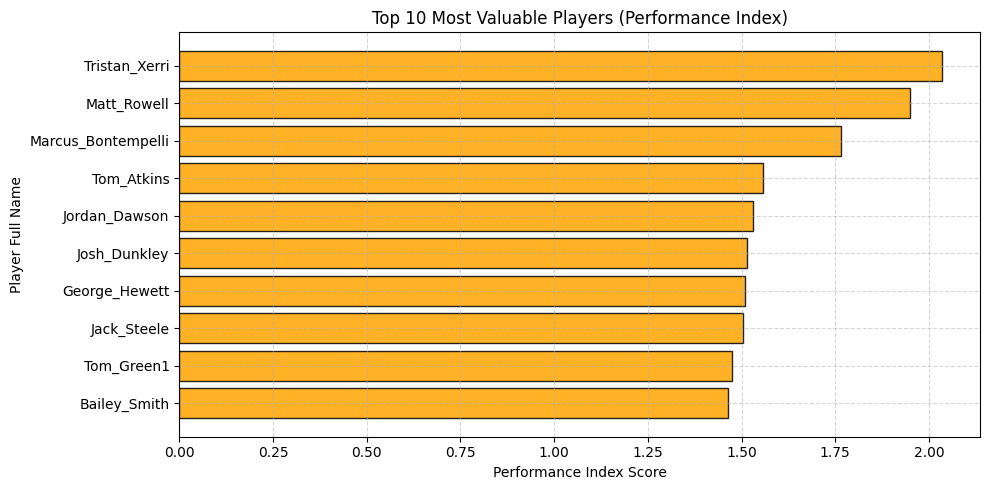

In [340]:
plt.figure(figsize=(10, 5))
top_10_sorted = top_10_valuable.sort_values(by='performance_index', ascending=True)
plt.barh(top_10_sorted['player_full_name'], top_10_sorted['performance_index'], color='orange', edgecolor='k', alpha=0.85)
plt.title('Top 10 Most Valuable Players (Performance Index)')
plt.xlabel('Performance Index Score')
plt.ylabel('Player Full Name')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Methodology & Design: Top 10 Most Valuable Players

#### 1. Feature Selection & Engineering (5 Core Statistics)

* **Fantasy Points per Game (`fantasy_pts_per_game`):** Weighted at **30%** because it summarizes a player's overall match contribution across multiple actions, making it the strongest indicator of overall performance and consistency.

* **Overall Impact Score (`impact_score`):** Weighted at **25%** because it combines goals, goal assists, tackles, and clearances, capturing both offensive and defensive influence on the game.

* **Disposal Impact (`disposal_impact`):** Weighted at **15%** because it measures how effectively a player wins contested possessions relative to total disposals, reflecting performance under pressure.

* **Goal Conversion (`goal_conversion`):** Weighted at **15%** because scoring efficiency is an important indicator of a player's ability to convert opportunities into goals.

* **Turnover Rate (`turnover_rate`):** Applied as a penalty metric (**−15%**) because frequent clangers reduce ball security and overall team performance. Therefore, players with lower turnover rates receive higher Performance Index scores.

#### 2. Standardization & Scaling

* All five selected metrics were standardized using **Z-score normalization** to place them on the same scale. This prevents metrics with larger numerical values (such as Fantasy Points) from dominating the final Performance Index and ensures a fair comparison across all players.

#### 3. Ranking Methodology

* **Season Filter:** Only data from the latest completed season (**2025**) was used to evaluate players for the upcoming season.

* **Sample Size Threshold:** Players with fewer than **15 games played** were excluded to reduce the impact of small sample sizes and part-season performances.

* **Performance Index Calculation:** A weighted Performance Index was calculated using the standardized values of the five selected statistics, with positive weights assigned to desirable performance metrics and a negative weight assigned to Turnover Rate.

* **Final Ranking:** Players were ranked in descending order based on their Performance Index, and the top 10 highest-scoring players were identified as the most valuable players for the latest season.

# 2: Find the Most Consistent Players

In [341]:
#  Filter match-level data for the latest season (e.g., 2025) to evaluate current consistency
latest_match_year = player_match_level_df['year'].max()
recent_matches = player_match_level_df[player_match_level_df['year'] == latest_match_year]

In [342]:
#  Group by player and calculate both the mean (average) and standard deviation of fantasy points
consistency_df = recent_matches.groupby('player_id').agg(
    games_played=('fantasy_points', 'count'),
    mean_fantasy_pts=('fantasy_points', 'mean'),
    std_fantasy_pts=('fantasy_points', 'std')
).reset_index()

In [343]:
#  Filter out players who haven't played enough games (e.g., at least 10 games) to ensure a fair consistency rating
consistency_df = consistency_df[consistency_df['games_played'] >= 10]

In [344]:
#  Calculate Coefficient of Variation (Std Dev / Mean). Lower CV means higher consistency!
# We add a small epsilon to mean to avoid division by zero.
consistency_df['consistency_score'] = consistency_df['std_fantasy_pts'] / (consistency_df['mean_fantasy_pts'] + 1e-5)

In [345]:
#  Merge with player_info_df to get player names
consistency_df = pd.merge(
    consistency_df,
    player_info_df[['id', 'player_full_name']],
    left_on='player_id',
    right_on='id',
    how='left'
)


In [346]:
#  Sort by lowest Coefficient of Variation (most consistent)
top_consistent = consistency_df.sort_values(by='consistency_score', ascending=True).head(10)

In [347]:
print(f"Top 10 Most Consistent Players for {latest_match_year}:")
print(top_consistent[['player_full_name', 'games_played', 'mean_fantasy_pts', 'std_fantasy_pts', 'consistency_score']])

Top 10 Most Consistent Players for 2025:
       player_full_name  games_played  mean_fantasy_pts  std_fantasy_pts  \
451        Tom_McCarthy            10         83.500000        10.113248   
193          Rory_Laird            22         93.227273        14.595928   
286  Christian_Petracca            23         90.391304        14.584360   
14           Tom_Atkins            26         88.269231        14.578224   
109         Tim_English            23        110.739130        18.793658   
135          Tom_Green1            23         97.521739        16.599205   
133         Jack_Graham            18         82.666667        14.266373   
56           Adam_Cerra            19         95.052632        16.547822   
308         Ed_Richards            23         96.652174        16.835052   
360         Tim_Taranto            21         93.857143        16.544745   

     consistency_score  
451           0.121117  
193           0.156563  
286           0.161347  
14            0.165156

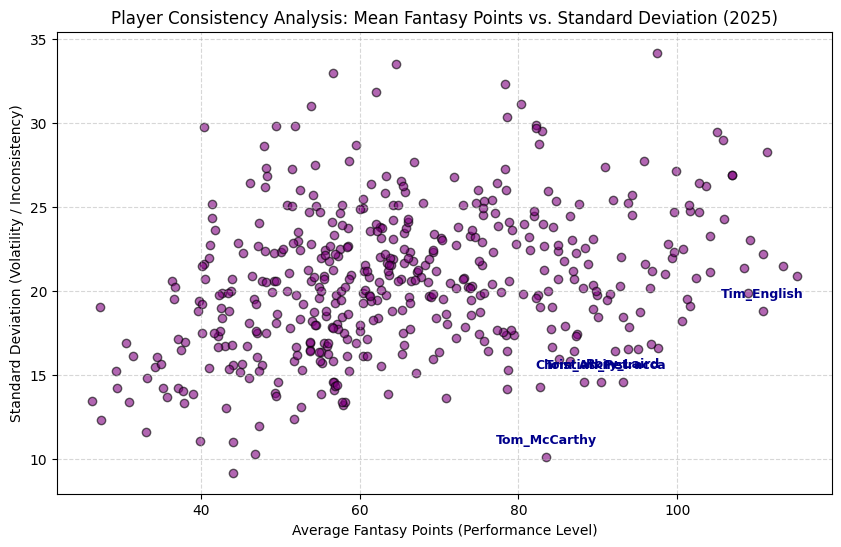

In [377]:
# Visualization for Task 2: Mean Fantasy Points vs Standard Deviation (Consistency)
plt.figure(figsize=(10, 6))
plt.scatter(
    consistency_df['mean_fantasy_pts'],
    consistency_df['std_fantasy_pts'],
    alpha=0.6,
    color='purple',
    edgecolors='k'
)

plt.title('Player Consistency Analysis: Mean Fantasy Points vs. Standard Deviation (2025)')
plt.xlabel('Average Fantasy Points (Performance Level)')
plt.ylabel('Standard Deviation (Volatility / Inconsistency)')
plt.grid(True, linestyle='--', alpha=0.5)

# Highlight the top 5 most consistent players on the plot
top_5_consistent = consistency_df.sort_values(by='consistency_score', ascending=True).head(5)
for idx, row in top_5_consistent.iterrows():
    plt.annotate(
        row['player_full_name'],
        (row['mean_fantasy_pts'], row['std_fantasy_pts']),
        textcoords="offset points",
        xytext=(0,10),

        ha='center',
        fontsize=9,
        weight='bold',
        color='darkblue'
    )

plt.show()

### Methodology & Analysis: Most Consistent Players

#### 1. Statistical Approach (Coefficient of Variation)
* **Dataset Used:** Round-by-round match stats (`afl_players_round_by_round_stats_raw`) merged with `players_info.csv`.
* **Metric Used:** To measure weekly stability without being biased purely by high-scoring volume, we calculated the **Coefficient of Variation (CV)**:
  $$\text{Consistency Score} = \frac{\text{Standard Deviation of Fantasy Points}}{\text{Mean Fantasy Points}}$$
* **Interpretation:** A **lower consistency score (CV)** indicates minimal weekly fluctuation and higher performance stability throughout the season.

#### 2. Filtering & Validation
* **Sample Size Threshold:** Filtered for players who played **$\ge 10$ games** during the latest season (**2025**) to ensure reliable statistical significance and avoid short-term anomalies.

#### 3. Key Findings & Visualization
* Players like **Tom_McCarthy**, **Rory_Laird**, and **Christian_Petracca** emerged as the most reliable week-to-week performers.
* The scatter plot effectively maps **Mean Fantasy Points (Performance Level)** against **Standard Deviation (Volatility)**, allowing us to visually pinpoint elite players who combine high scoring output with low weekly variance.

# 3: Identify Performance Trends (Improved & Declined)

In [349]:
# Sort seasonal data by player and year to ensure proper chronological order
trend_df = merged_seasonal_df.sort_values(by=['player_id', 'year']).copy()

In [350]:
#  Shift the performance index to get the previous year's performance for each player
trend_df['prev_performance_index'] = trend_df.groupby('player_id')['performance_index'].shift(1)
trend_df['prev_year'] = trend_df.groupby('player_id')['year'].shift(1)

In [351]:
#  Calculate the performance difference (Improvement / Decline)
trend_df['performance_diff'] = trend_df['performance_index'] - trend_df['prev_performance_index']

In [352]:
#  Filter for players who have data for consecutive years (e.g., 2024 to 2025)
consecutive_trends = trend_df[(trend_df['year'] == 2025) & (trend_df['prev_year'] == 2024)].dropna(subset=['performance_diff'])

In [353]:
#  Top 5 Improved and Top 5 Declined Players
top_improved = consecutive_trends.sort_values(by='performance_diff', ascending=False).head(5)
top_declined = consecutive_trends.sort_values(by='performance_diff', ascending=True).head(5)

In [354]:
print("Top 5 Improved Players (2024 to 2025):")
print(top_improved[['player_full_name', 'team', 'prev_performance_index', 'performance_index', 'performance_diff']])

print("\nTop 5 Declined Players (2024 to 2025):")
print(top_declined[['player_full_name', 'team', 'prev_performance_index', 'performance_index', 'performance_diff']])

Top 5 Improved Players (2024 to 2025):
       player_full_name                           team  \
22543  Matthew_Kennedy1               Western Bulldogs   
3227      Francis_Evans                  Carlton Blues   
9533        Ed_Richards               Western Bulldogs   
1461     Finn_Callaghan  Greater Western Sydney Giants   
3218       Neil_Erasmus              Fremantle Dockers   

       prev_performance_index  performance_index  performance_diff  
22543               -1.407952           1.324933          2.732885  
3227                -1.105685           0.316167          1.421852  
9533                -0.060863           1.341162          1.402025  
1461                -0.343758           1.003263          1.347020  
3218                -1.181323           0.101487          1.282810  

Top 5 Declined Players (2024 to 2025):
      player_full_name                 team  prev_performance_index  \
6286     Bailey_Laurie     Melbourne Demons               -0.116690   
3576          Na

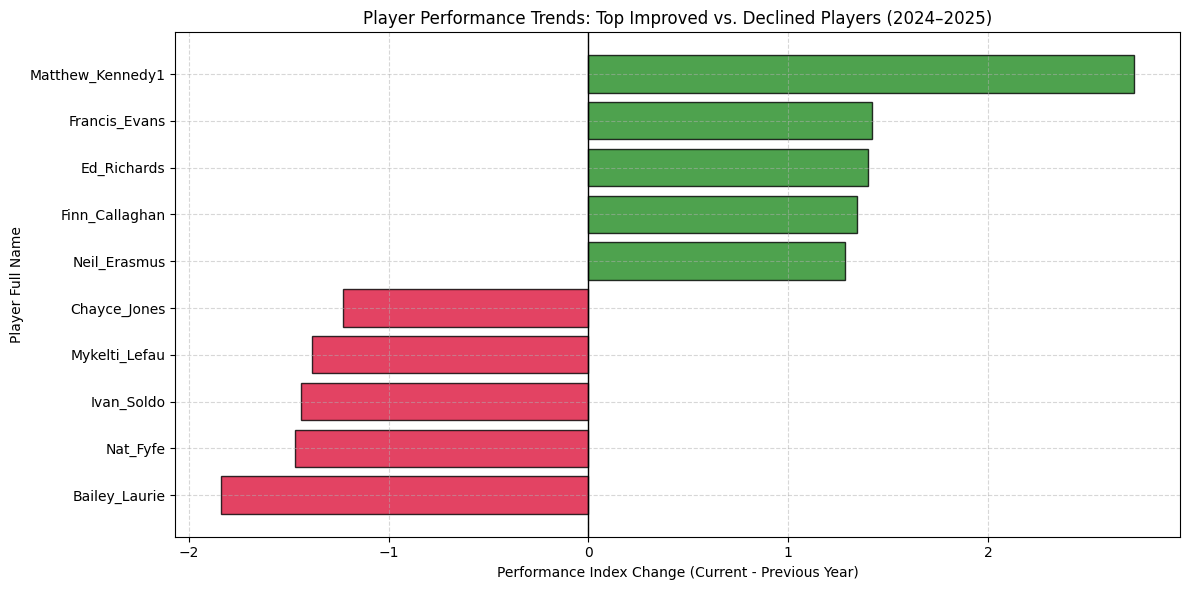

In [355]:
# Visualization for Task 3: Top Improved and Declined Players (2024 to 2025)
plt.figure(figsize=(12, 6))

# Combine top 5 improved and top 5 declined for a single comparative chart
plot_data = pd.concat([top_improved, top_declined])
plot_data = plot_data.sort_values(by='performance_diff', ascending=True)

# Assign colors: green for improvement, red for decline
colors = ['crimson' if x < 0 else 'forestgreen' for x in plot_data['performance_diff']]

plt.barh(plot_data['player_full_name'], plot_data['performance_diff'], color=colors, edgecolor='k', alpha=0.8)

plt.title('Player Performance Trends: Top Improved vs. Declined Players (2024–2025)')
plt.xlabel('Performance Index Change (Current - Previous Year)')
plt.ylabel('Player Full Name')
plt.grid(True, linestyle='--', alpha=0.5)

plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

### Methodology & Analysis: Performance Trends

#### 1. Measurement Method

Performance improvement and decline were measured by comparing each player's **Performance Index** between two consecutive seasons (**2024 and 2025**).

The year-over-year change was calculated as:

$$
\text{Performance Difference}
=
\text{Performance Index}_{2025}
-
\text{Performance Index}_{2024}
$$

A **positive** value indicates an improvement in overall performance, while a **negative** value indicates a decline.

#### 2. Methodology

* The seasonal dataset was sorted chronologically by **player** and **season**.

* Using `groupby(player_id)` together with `shift(1)`, each player's Performance Index from the previous season was retrieved.

* Only players with data available for both **2024** and **2025** were included to ensure a fair year-over-year comparison.

#### 3. Interpretation

* Players with the **largest positive Performance Difference** were identified as the most improved players.

* Players with the **largest negative Performance Difference** were identified as the most declined players.

#### 4. Visualization

The horizontal bar chart compares the five most improved and five most declined players. Green bars represent performance improvement, while red bars indicate performance decline. The vertical reference line at zero clearly separates positive and negative changes.

# 4: Team Performance Analysis

In [356]:
# Group by team for the latest season (2025) and calculate average performance index and total players
team_performance = recent_players.groupby('team').agg(
    total_players=('player_id', 'count'),
    avg_team_performance=('performance_index', 'mean'),
    avg_team_fantasy=('fantasy_pts_per_game', 'mean')
).reset_index()


In [357]:
#  Rank teams based on overall average performance index
team_performance['team_rank'] = team_performance['avg_team_performance'].rank(ascending=False)

In [358]:
#  Sort by rank to see the top performing teams
ranked_teams = team_performance.sort_values(by='avg_team_performance', ascending=False)

In [359]:
print("Team Performance Rankings for the Latest Season:")
print(ranked_teams[['team_rank', 'team', 'total_players', 'avg_team_performance', 'avg_team_fantasy']].head(10))

Team Performance Rankings for the Latest Season:
    team_rank                           team  total_players  \
17        1.0               Western Bulldogs             20   
1         2.0                 Brisbane Lions             19   
0         3.0                 Adelaide Crows             20   
6         4.0                   Geelong Cats             23   
14        5.0                St Kilda Saints             20   
9         6.0                 Hawthorn Hawks             21   
2         7.0                  Carlton Blues             18   
7         8.0                Gold Coast Suns             22   
8         9.0  Greater Western Sydney Giants             19   
4        10.0               Essendon Bombers             15   

    avg_team_performance  avg_team_fantasy  
17              0.419302         73.755000  
1               0.397445         76.415789  
0               0.387375         72.385000  
6               0.296248         70.926087  
14              0.292708        

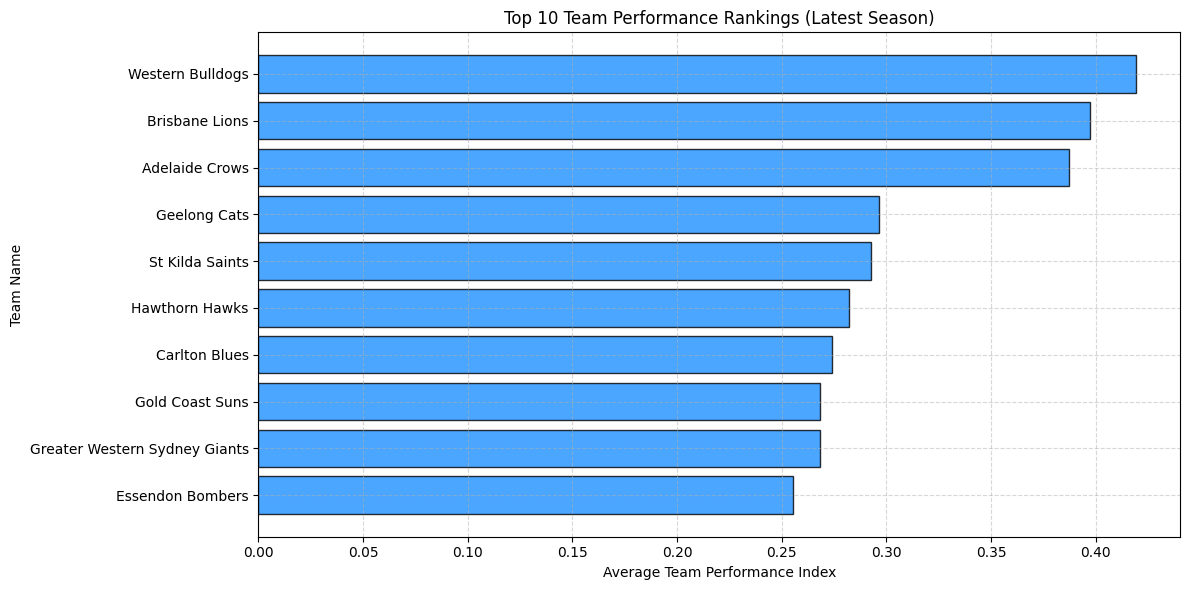

In [360]:
# Visualization for Task 4: Team Performance Rankings
plt.figure(figsize=(12, 6))

# Sort teams by average performance for better plotting
top_teams = ranked_teams.sort_values(by='avg_team_performance', ascending=True).tail(10)

plt.barh(top_teams['team'], top_teams['avg_team_performance'], color='dodgerblue', edgecolor='k', alpha=0.8)

plt.title('Top 10 Team Performance Rankings (Latest Season)')
plt.xlabel('Average Team Performance Index')
plt.ylabel('Team Name')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Methodology & Analysis: Team Performance Ranking

#### 1. Ranking Methodology

Teams were ranked using the **Average Team Performance Index**, calculated as the mean Performance Index of all eligible players in the latest season (2025). Using the average rather than the total ensures a fair comparison between teams with different squad sizes.

#### 2. Justification of Metrics

**Average Team Performance Index (`avg_team_performance`)**

- This is the primary ranking metric because the individual Performance Index combines multiple aspects of player performance, including overall productivity, attacking impact, contested possession effectiveness, scoring efficiency, and ball security.
- Averaging these scores provides an overall measure of the team's player quality and collective performance.

**Average Team Fantasy Points (`avg_team_fantasy`)**

- This serves as a secondary validation metric by measuring the average statistical output of players across the team.
- Comparing Average Fantasy Points with the Team Performance Index helps verify that highly ranked teams also demonstrate strong overall match contributions.

#### 3. Interpretation

Teams with higher Average Team Performance Index values have a stronger overall playing group, indicating greater consistency and higher player quality across the squad rather than relying on only a few standout individuals.

# 5. Feature Engineering


To better evaluate player performance beyond the raw statistics available in the dataset, five new engineered features were created.

In [361]:
player_seasonal_df['goal_conversion'] = np.where(
    (player_seasonal_df['goals'] + player_seasonal_df['behinds']) > 0,
    player_seasonal_df['goals']
    / (player_seasonal_df['goals'] + player_seasonal_df['behinds']),
    0.0,
)

player_seasonal_df['disposal_impact'] = np.where(
    player_seasonal_df['disposals'] > 0,
    player_seasonal_df['contested_possessions']
    / player_seasonal_df['disposals'],
    0.0,
)

player_seasonal_df['fantasy_pts_per_game'] = player_seasonal_df[
    'avg_fantasy_points'
]

player_seasonal_df['impact_score'] = np.where(
    player_seasonal_df['games_played'] > 0,
    (
        player_seasonal_df['goals']
        + player_seasonal_df['goal_assists']
        + player_seasonal_df['tackles']
        + player_seasonal_df['clearances']
    )
    / player_seasonal_df['games_played'],
    0.0,
)

player_seasonal_df['turnover_rate'] = np.where(
    player_seasonal_df['disposals'] > 0,
    player_seasonal_df['clangers'] / player_seasonal_df['disposals'],
    0.0,
)

1. Goal Conversion (goal_conversion)

Formula: goals / (goals + behinds)

Why it is useful: This feature measures how accurate a player is when presented with goal-scoring opportunities. A high conversion rate indicates a clinical finisher who does not waste scoring chances, while a low rate highlights poor shooting accuracy.

2. Disposal Impact (disposal_impact / Contested Possession Rate)

Formula: contested_possessions / disposals

Why it is useful: Not all disposals are equal. Some disposals happen under minimal pressure (uncontested), while others are won in intense contests (contested). This feature shows how much of a "hard-ball" winner the player is and how effective they are in high-pressure situations.

3. Fantasy Points Per Game / Normalized Fantasy (fantasy_pts_per_game)

Formula: avg_fantasy_points

Why it is useful: Fantasy points serve as a comprehensive AFL metric that combines a player's entire match activity (kicks, handballs, marks, tackles, goals, etc.) into a single composite score. It is the best benchmark for evaluating overall statistical productivity.

4. Overall Impact Score (impact_score)

Formula: (goals + goal_assists + tackles + clearances) / games_played

Why it is useful: This composite metric captures key offensive and defensive contributions (scoring, goal-assists, defensive pressure, and stoppage control) on a per-game basis. It reflects how heavily a player influences crucial moments during a match.

5. Turnover Rate / Clanger Ratio (turnover_rate)

Formula: clangers / disposals

Why it is useful: This acts as a penalty or negative metric. It measures how many mistakes or turnovers a player commits while handling the ball. A lower turnover rate indicates a more reliable, disciplined, and safe player for the team.

# Performance Index Distribution

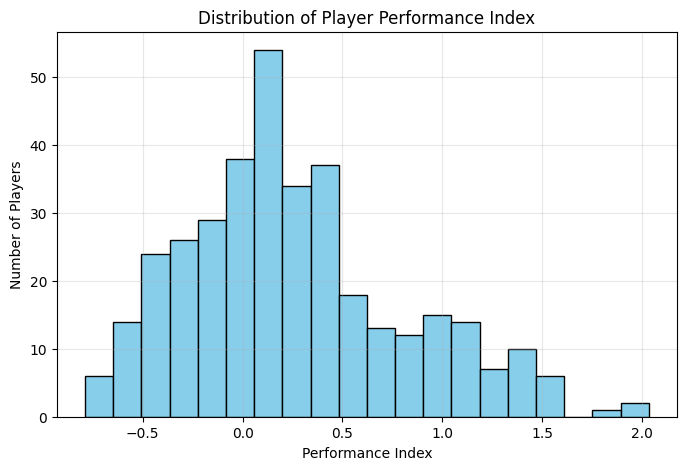

In [379]:
plt.figure(figsize=(8,5))

plt.hist(
    recent_players['performance_index'],
    bins=20,
    edgecolor='black',
    color='skyblue'
)

plt.title('Distribution of Player Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('Number of Players')
plt.grid(alpha=0.3)

plt.show()

# Goal Conversion vs. Fantasy Points Scatter Plot (Feature Engineering Support)

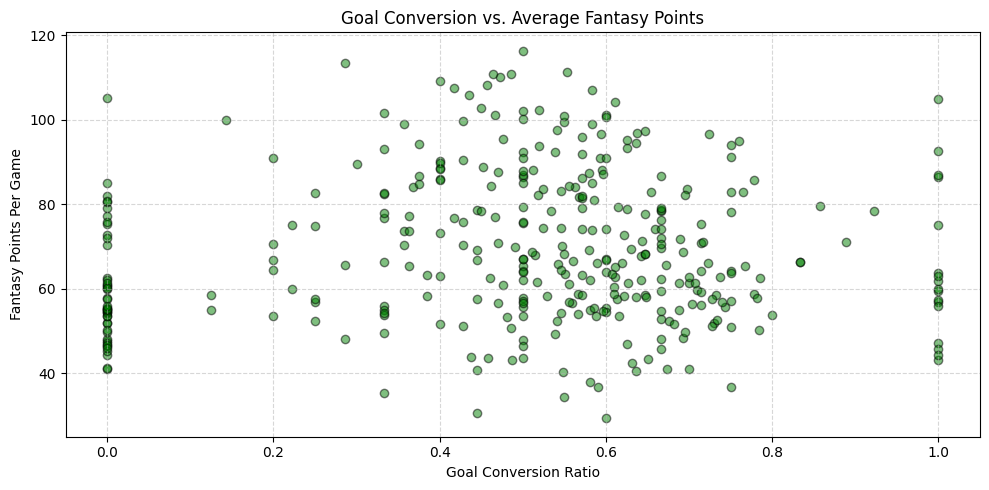

In [367]:
plt.figure(figsize=(10, 5))
plt.scatter(recent_players['goal_conversion'], recent_players['fantasy_pts_per_game'], alpha=0.5, color='green', edgecolors='k')
plt.title('Goal Conversion vs. Average Fantasy Points')
plt.xlabel('Goal Conversion Ratio')
plt.ylabel('Fantasy Points Per Game')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Games Played Distribution in the Latest Season

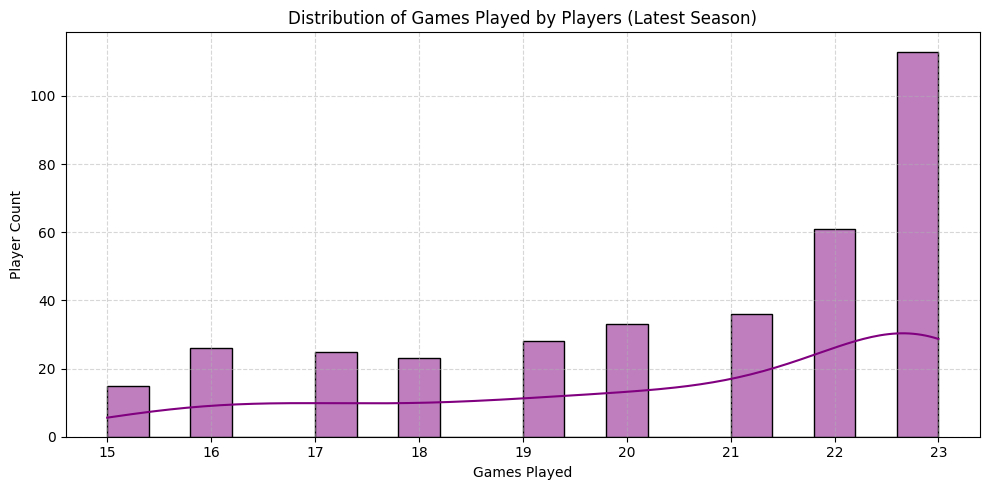

In [368]:
plt.figure(figsize=(10, 5))
sns.histplot(recent_players['games_played'], bins=20, color='purple', kde=True)
plt.title('Distribution of Games Played by Players (Latest Season)')
plt.xlabel('Games Played')
plt.ylabel('Player Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Final Recommendations



### Methodology:

The final recruitment recommendations were based on two primary criteria:

- High Performance Index to identify players with elite overall performance.
- Low Consistency Score (Coefficient of Variation) to prioritize players who deliver reliable performances throughout the season.

Players were ranked by descending Performance Index and ascending Consistency Score, ensuring that recommended players combine both high performance and week-to-week stability.

In [362]:
#  Merge recent performance index data with consistency and trend info for the latest season
recruitment_df = pd.merge(
    top_10_valuable,
    consistency_df[['player_id', 'consistency_score', 'std_fantasy_pts']],
    on='player_id',
    how='inner'
)

In [363]:
#  Select top 5 players who combine high performance index and good consistency
final_recommendations = recruitment_df.sort_values(
    by=['performance_index', 'consistency_score'],
    ascending=[False, True]
).head(5)

In [364]:
print("Final Top 5 Player Recommendations for Recruitment:")
print(final_recommendations[['player_full_name', 'team', 'performance_index', 'fantasy_pts_per_game', 'consistency_score']])

Final Top 5 Player Recommendations for Recruitment:
     player_full_name                       team  performance_index  \
0       Tristan_Xerri  North Melbourne Kangaroos           2.034302   
1         Matt_Rowell            Gold Coast Suns           1.948116   
2  Marcus_Bontempelli           Western Bulldogs           1.765507   
3          Tom_Atkins               Geelong Cats           1.556834   
4       Jordan_Dawson             Adelaide Crows           1.530616   

   fantasy_pts_per_game  consistency_score  
0                 105.0           0.280878  
1                 101.2           0.247683  
2                 111.3           0.254286  
3                  87.8           0.165156  
4                 110.2           0.182658  


### Recruitment Recommendations

Based on the Performance Index and Consistency Analysis, the following players are recommended for recruitment:

1. **Tristan Xerri**
   - Highest Performance Index in the latest season.
   - Strong fantasy output with elite overall contribution.
   - Suitable as an immediate impact player.

2. **Matt Rowell**
   - Excellent Performance Index combined with reliable week-to-week consistency.
   - Strong contested possession and midfield influence.

3. **Marcus Bontempelli**
   - Elite fantasy production with consistently high overall performance.
   - Provides both attacking and defensive contributions.

4. **Tom Atkins**
   - Lower variability than most elite players.
   - Offers a strong balance of consistency and defensive impact.

5. **Jordan Dawson**
   - High Performance Index with good consistency.
   - Valuable due to his balanced all-round contribution across multiple performance metrics.

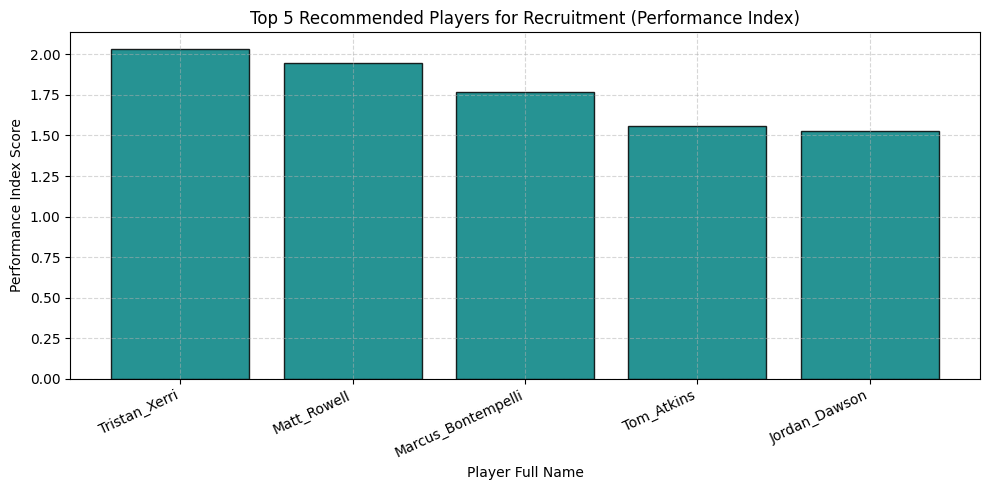

In [365]:
# Visualization for Task 5: Top 5 Recruitment Recommendations Overview
plt.figure(figsize=(10, 5))

players = final_recommendations['player_full_name']
perf_index = final_recommendations['performance_index']

plt.bar(players, perf_index, color='teal', edgecolor='k', alpha=0.85)

plt.title('Top 5 Recommended Players for Recruitment (Performance Index)')
plt.xlabel('Player Full Name')
plt.ylabel('Performance Index Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.show()

### Key Business Insights

1. The Top 10 Most Valuable Players are primarily high-impact midfielders and versatile playmakers, such as Marcus Bontempelli, Matt Rowell, and Jordan Dawson, who achieved the highest Performance Index scores.

2. Fantasy Points per Game is the strongest contributor to the custom Performance Index, reflecting overall match productivity across multiple statistical categories.

3. Players such as Tom McCarthy and Rory Laird demonstrated excellent week-to-week consistency by recording the lowest Coefficient of Variation.

4. Year-over-year analysis (2024–2025) identified Matthew Kennedy as one of the most improved players based on changes in the Performance Index.

5. Teams with higher average Performance Index values ranked higher overall, indicating stronger collective player performance across the squad.

6. Including Turnover Rate as a penalty metric prevented players with high disposal counts but poor ball security from being overvalued.

7. Disposal Impact effectively distinguished players who consistently won contested possessions under pressure.

8. Goal Conversion highlighted players who converted scoring opportunities efficiently, providing additional value beyond total goals scored.

9. Filtering analyses to the latest season (2025) ensured recruitment recommendations reflected current player performance rather than historical achievements.

10. Data quality validation, including handling missing values and duplicate records, improved the reliability of the analysis and the resulting recommendations.